## 9. Part 1 - Random Forest Hyperparameter Optimization

### 1. Importing libraries

### 2. Importing data

### 3. Data wrangling

### 4. Creating subsets

### 5. Checking the number of entries per station

### 6. Dropping columns

### 7. Data splitting

### 8. Grid Search

### 9. Random Search

### 10. Running random forest with optimized hyperparameters

### 11. Feature importances

### 12. Subset and random forest for Munchenb

### 13. Grid Search for Munchenb

### 14. Random Search for Munchenb

### 15. Running random forest with optimized hyperparameters

#### 1. Importing libraries

In [14]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
import time
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

#### 2. Importing data

In [16]:
path = r'C:\Users\Priya\OneDrive\Documents\CareerFoundry\Machine Learning'

In [17]:
path

'C:\\Users\\Priya\\OneDrive\\Documents\\CareerFoundry\\Machine Learning'

In [18]:
# Importing the cleaned weather observations data set
climate_cleaned = pd.read_csv(os.path.join(path, 'Achievement 2', 'Data Sets', 'weather_cleaned.csv'), index_col = False)

In [19]:
# Checking the shape of the dataframe
climate_cleaned.shape

(22950, 136)

In [20]:
# Viewing the first five rows of the dataframe
climate_cleaned.head()

,Unnamed: 0,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [21]:
# Dropping the Unnamed: 0 column
climate_cleaned = climate_cleaned.drop(['Unnamed: 0'], axis=1)

In [22]:
# Checking the shape of the dataframe
climate_cleaned.shape

(22950, 135)

In [23]:
# Checking if the Unnamed: 0 column was dropped
climate_cleaned.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,8,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [24]:
# Importing the pleasant weather dataset
pleasantweather = pd.read_csv(os.path.join(path, 'Achievement 1', 'Data Sets', 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'), index_col = False)

In [25]:
# Checking the shape of the pleasantweather dataset
pleasantweather.shape

(22950, 16)

In [26]:
# Viewing the first five rows of the pleasant weather dataset
pleasantweather.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
# Importing the original ClimateWins dataset to copy the DATE and MONTH columns to the climate_cleaned dataset
climate = pd.read_csv(os.path.join(path, 'Achievement 1', 'Data Sets', 'Dataset-weather-prediction-dataset-processed.csv'), index_col = False)

In [28]:
# Checking the shape of the climate dataframe
climate.shape

(22950, 170)

In [29]:
# Viewing the first five rows of the climate dataframe
climate.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,2.1,0.85,1.018,0.32,0.09,0,0.7,...,5,0.88,1.0003,0.45,0.34,0,4.7,8.5,6.0,10.9
1,19600102,1,6,2.1,0.84,1.018,0.36,1.05,0,1.1,...,7,0.91,1.0007,0.25,0.84,0,0.7,8.9,5.6,12.1
2,19600103,1,8,2.1,0.90,1.018,0.18,0.30,0,0.0,...,7,0.91,1.0096,0.17,0.08,0,0.1,10.5,8.1,12.9
3,19600104,1,3,2.1,0.92,1.018,0.58,0.00,0,4.1,...,7,0.86,1.0184,0.13,0.98,0,0.0,7.4,7.3,10.6
4,19600105,1,6,2.1,0.95,1.018,0.65,0.14,0,5.4,...,3,0.80,1.0328,0.46,0.00,0,5.7,5.7,3.0,8.4


#### 3. Data wrangling

In [31]:
# Adding the DATE and MONTH columns from climate to climate_cleaned since climate_cleaned does not have these columns
climate_cleaned[['DATE', 'MONTH']] = climate[['DATE', 'MONTH']].copy()

In [32]:
# Checking if the DATE and MONTH columns were added to climate_cleaned
climate_cleaned.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,DATE,MONTH
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,...,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9,19600101,1
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,...,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1,19600102,1
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,...,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9,19600103,1
3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,8,...,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6,19600104,1
4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,8,...,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4,19600105,1


#### 4. Creating subsets

In [34]:
# Creating a subset with data from 2011-2021
climatedecade = climate_cleaned[(climate_cleaned['DATE'].astype(str).str[:4] >= '2011') & (climate_cleaned['DATE'].astype(str).str[:4] < '2021')]
climatedecade

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max,DATE,MONTH
18628,8,0.97,1.0232,0.13,0.00,0.0,-0.2,-0.8,0.3,4,...,0.82,1.0142,0.13,0.41,3.4,10.7,7.9,6.6,20110101,1
18629,8,0.94,1.0234,0.13,0.00,0.0,-0.2,-3.9,1.4,8,...,0.82,1.0142,0.15,0.41,3.4,10.7,7.9,5.4,20110102,1
18630,4,0.93,1.0254,0.64,0.00,6.1,-3.3,-5.2,-0.9,7,...,0.82,1.0142,0.17,0.41,3.4,10.7,7.9,4.5,20110103,1
18631,6,0.89,1.0208,0.38,0.00,1.0,-3.6,-5.8,-1.9,4,...,0.82,1.0142,0.22,0.41,3.4,10.7,7.9,7.9,20110104,1
18632,5,0.79,1.0142,0.64,0.06,6.5,-0.8,-5.4,2.5,1,...,0.82,1.0142,0.23,0.41,3.4,10.7,7.9,7.8,20110105,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22276,8,0.70,1.0007,0.26,0.41,0.0,1.7,-3.6,9.9,7,...,0.82,1.0142,1.13,0.41,3.4,10.7,7.9,13.5,20201227,12
22277,7,0.74,0.9828,0.26,0.11,0.4,4.6,1.9,8.1,4,...,0.82,1.0142,1.13,0.41,3.4,10.7,7.9,13.5,20201228,12
22278,6,0.74,0.9945,0.25,0.22,0.2,4.4,1.6,6.9,2,...,0.82,1.0142,1.13,0.41,3.4,10.7,7.9,13.5,20201229,12
22279,6,0.85,1.0069,0.32,0.04,0.3,2.6,0.5,4.9,7,...,0.82,1.0142,1.13,0.41,3.4,10.7,7.9,13.5,20201230,12


In [35]:
# Creating a subset of the pleasantweather data set with data from 2011-2021
pleasantweatherdecade = pleasantweather[(pleasantweather['DATE'].astype(str).str[:4] >= '2011') & (pleasantweather['DATE'].astype(str).str[:4] < '2021')]
pleasantweatherdecade

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18628,20110101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18629,20110102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18630,20110103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18631,20110104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18632,20110105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22276,20201227,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22277,20201228,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22278,20201229,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22279,20201230,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


#### 5. Checking the number of entries per station

In [37]:
# Removing the limit on the number of rows that can be shown
pd.options.display.max_rows = None

In [38]:
# Extracting a list of weather station names
stations = [col.split('_')[0] for col in climatedecade.columns if '_' in col]

In [39]:
# Converting the list of stations into a set and viewing the set
unique_stations = set(stations)
unique_stations

{'BASEL',
 'BELGRADE',
 'BUDAPEST',
 'DEBILT',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MADRID',
 'MUNCHENB',
 'OSLO',
 'SONNBLICK',
 'STOCKHOLM',
 'VALENTIA'}

In [40]:
# Creating station_entries to store the number of entries for each station
station_entries = {}

for station in unique_stations:
    # Selecting columns for each station
    station_columns = [col for col in climatedecade.columns if col.startswith(station)]
    
    # Counting non-missing entries for each station
    station_entries[station] =  climatedecade[station_columns].notna().sum().sum()

In [41]:
# Printing the number of entries for each station
print("Number of entries for each weather station:")
for station, freq in station_entries.items():
    print(f"{station}: {freq}")

Number of entries for each weather station:
BUDAPEST: 32877
MAASTRICHT: 32877
KASSEL: 32877
STOCKHOLM: 32877
MUNCHENB: 32877
VALENTIA: 32877
DUSSELDORF: 32877
DEBILT: 32877
LJUBLJANA: 32877
HEATHROW: 32877
MADRID: 32877
BASEL: 32877
SONNBLICK: 32877
OSLO: 32877
BELGRADE: 32877


#### 6. Dropping columns

In [43]:
# Dropping the DATE and MONTH columns from the climatedecade dataframe
climatedecade = climatedecade.drop(['DATE', 'MONTH'], axis=1)

In [44]:
# Checking the shape of the climatedecade dataframe
climatedecade.shape

(3653, 135)

In [45]:
# Checking if the DATE and MONTH columns were dropped from climatedecade
climatedecade.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
18628,8,0.97,1.0232,0.13,0.00,0.0,-0.2,-0.8,0.3,4,...,-0.5,5,0.82,1.0142,0.13,0.41,3.4,10.7,7.9,6.6
18629,8,0.94,1.0234,0.13,0.00,0.0,-0.2,-3.9,1.4,8,...,-2.4,5,0.82,1.0142,0.15,0.41,3.4,10.7,7.9,5.4
18630,4,0.93,1.0254,0.64,0.00,6.1,-3.3,-5.2,-0.9,7,...,-2.6,5,0.82,1.0142,0.17,0.41,3.4,10.7,7.9,4.5
18631,6,0.89,1.0208,0.38,0.00,1.0,-3.6,-5.8,-1.9,4,...,-5.6,5,0.82,1.0142,0.22,0.41,3.4,10.7,7.9,7.9
18632,5,0.79,1.0142,0.64,0.06,6.5,-0.8,-5.4,2.5,1,...,-0.2,5,0.82,1.0142,0.23,0.41,3.4,10.7,7.9,7.8


In [46]:
# Dropping the DATE column from the pleasantweatherdecade dataframe
pleasantweatherdecade = pleasantweatherdecade.drop(['DATE'], axis=1)

In [47]:
# Checking the shape of pleasantweatherdecade
pleasantweatherdecade.shape

(3653, 15)

In [48]:
# Checking if the DATE column was dropped from pleasantweatherdecade
pleasantweatherdecade.head()

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18628,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18629,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18630,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18631,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18632,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [49]:
# Renaming the climatedecade and pleasantweatherdecade dataframes to X and y, respectively
X = climatedecade
y = pleasantweatherdecade

In [50]:
# Converting X and Y into arrays
X = np.array(X)
y = np.array(y)

In [51]:
# Viewing X
X

array([[ 8.    ,  0.97  ,  1.0232, ..., 10.7   ,  7.9   ,  6.6   ],
       [ 8.    ,  0.94  ,  1.0234, ..., 10.7   ,  7.9   ,  5.4   ],
       [ 4.    ,  0.93  ,  1.0254, ..., 10.7   ,  7.9   ,  4.5   ],
       ...,
       [ 6.    ,  0.74  ,  0.9945, ..., 10.7   ,  7.9   , 13.5   ],
       [ 6.    ,  0.85  ,  1.0069, ..., 10.7   ,  7.9   , 13.5   ],
       [ 7.    ,  0.86  ,  1.0069, ..., 10.7   ,  7.9   , 13.5   ]])

In [52]:
# Viewing y
y

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [53]:
# Checking the shape of X
X.shape

(3653, 135)

In [54]:
# Checking the shape of y
y.shape

(3653, 15)

#### 7. Data splitting

In [56]:
# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [57]:
# Printing the shapes of X_train, X_test, y_train, and y_test
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2739, 135) (2739, 15)
(914, 135) (914, 15)


#### 8. Grid Search

In [59]:
# Creating a RF classifier
clf = RandomForestClassifier()

In [60]:
# Grid search cv with a smaller number of iterations
grid_space={'max_depth':[3,10,None],
              'n_estimators':[10,100],
              'max_features':[15,50],
              'min_samples_leaf':[1,2],
              'min_samples_split':[2,3]
           }

In [101]:
start = time.time()
grid = GridSearchCV(clf,param_grid=grid_space,cv=3,scoring='accuracy', verbose=3, n_jobs=-1)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Search took 3.5326260725657144 minutes


In [103]:
# Printing grid search results
print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': None, 'max_features': 50, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 100}
Best GRID search score is: 0.6473165388828039


#### 9. Random Search

In [106]:
# Random search cv
rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(15, 135),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1, 4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [108]:
# Creating a RF classifier
clf2= RandomForestClassifier()

In [110]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=10, scoring='accuracy', verbose=3, n_jobs=-1, cv=3) #500
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Search took 17.595853265126546 minutes


In [112]:
# Printing random search results
print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 70, 'max_features': 41, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 310}
Best RANDOM search score is: 0.6462212486308871


In [114]:
# Printing grid search results vs.
print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))
# Printing random search results
print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best GRID search hyperparameters are: {'max_depth': None, 'max_features': 50, 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 100}
Best GRID search score is: 0.6473165388828039
Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 70, 'max_features': 41, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 310}
Best RANDOM search score is: 0.6462212486308871


The Grid Search has a better accuracy score. The Grid Search hyperparameters will be used for the random forest.

#### 10. Running random forest with optimized hyperparameters

In [118]:
# Creating a RF classifier with the best results from above
clf3 = RandomForestClassifier(n_estimators = 100, max_depth=None, max_features=50, min_samples_leaf=2, min_samples_split=3, criterion = 'entropy')  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_features=50, min_samples_leaf=2,
                       min_samples_split=3)

In [120]:
# Performing predictions on the test dataset
y_pred = clf3.predict(X_test)
  
# Using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.6805251641137856


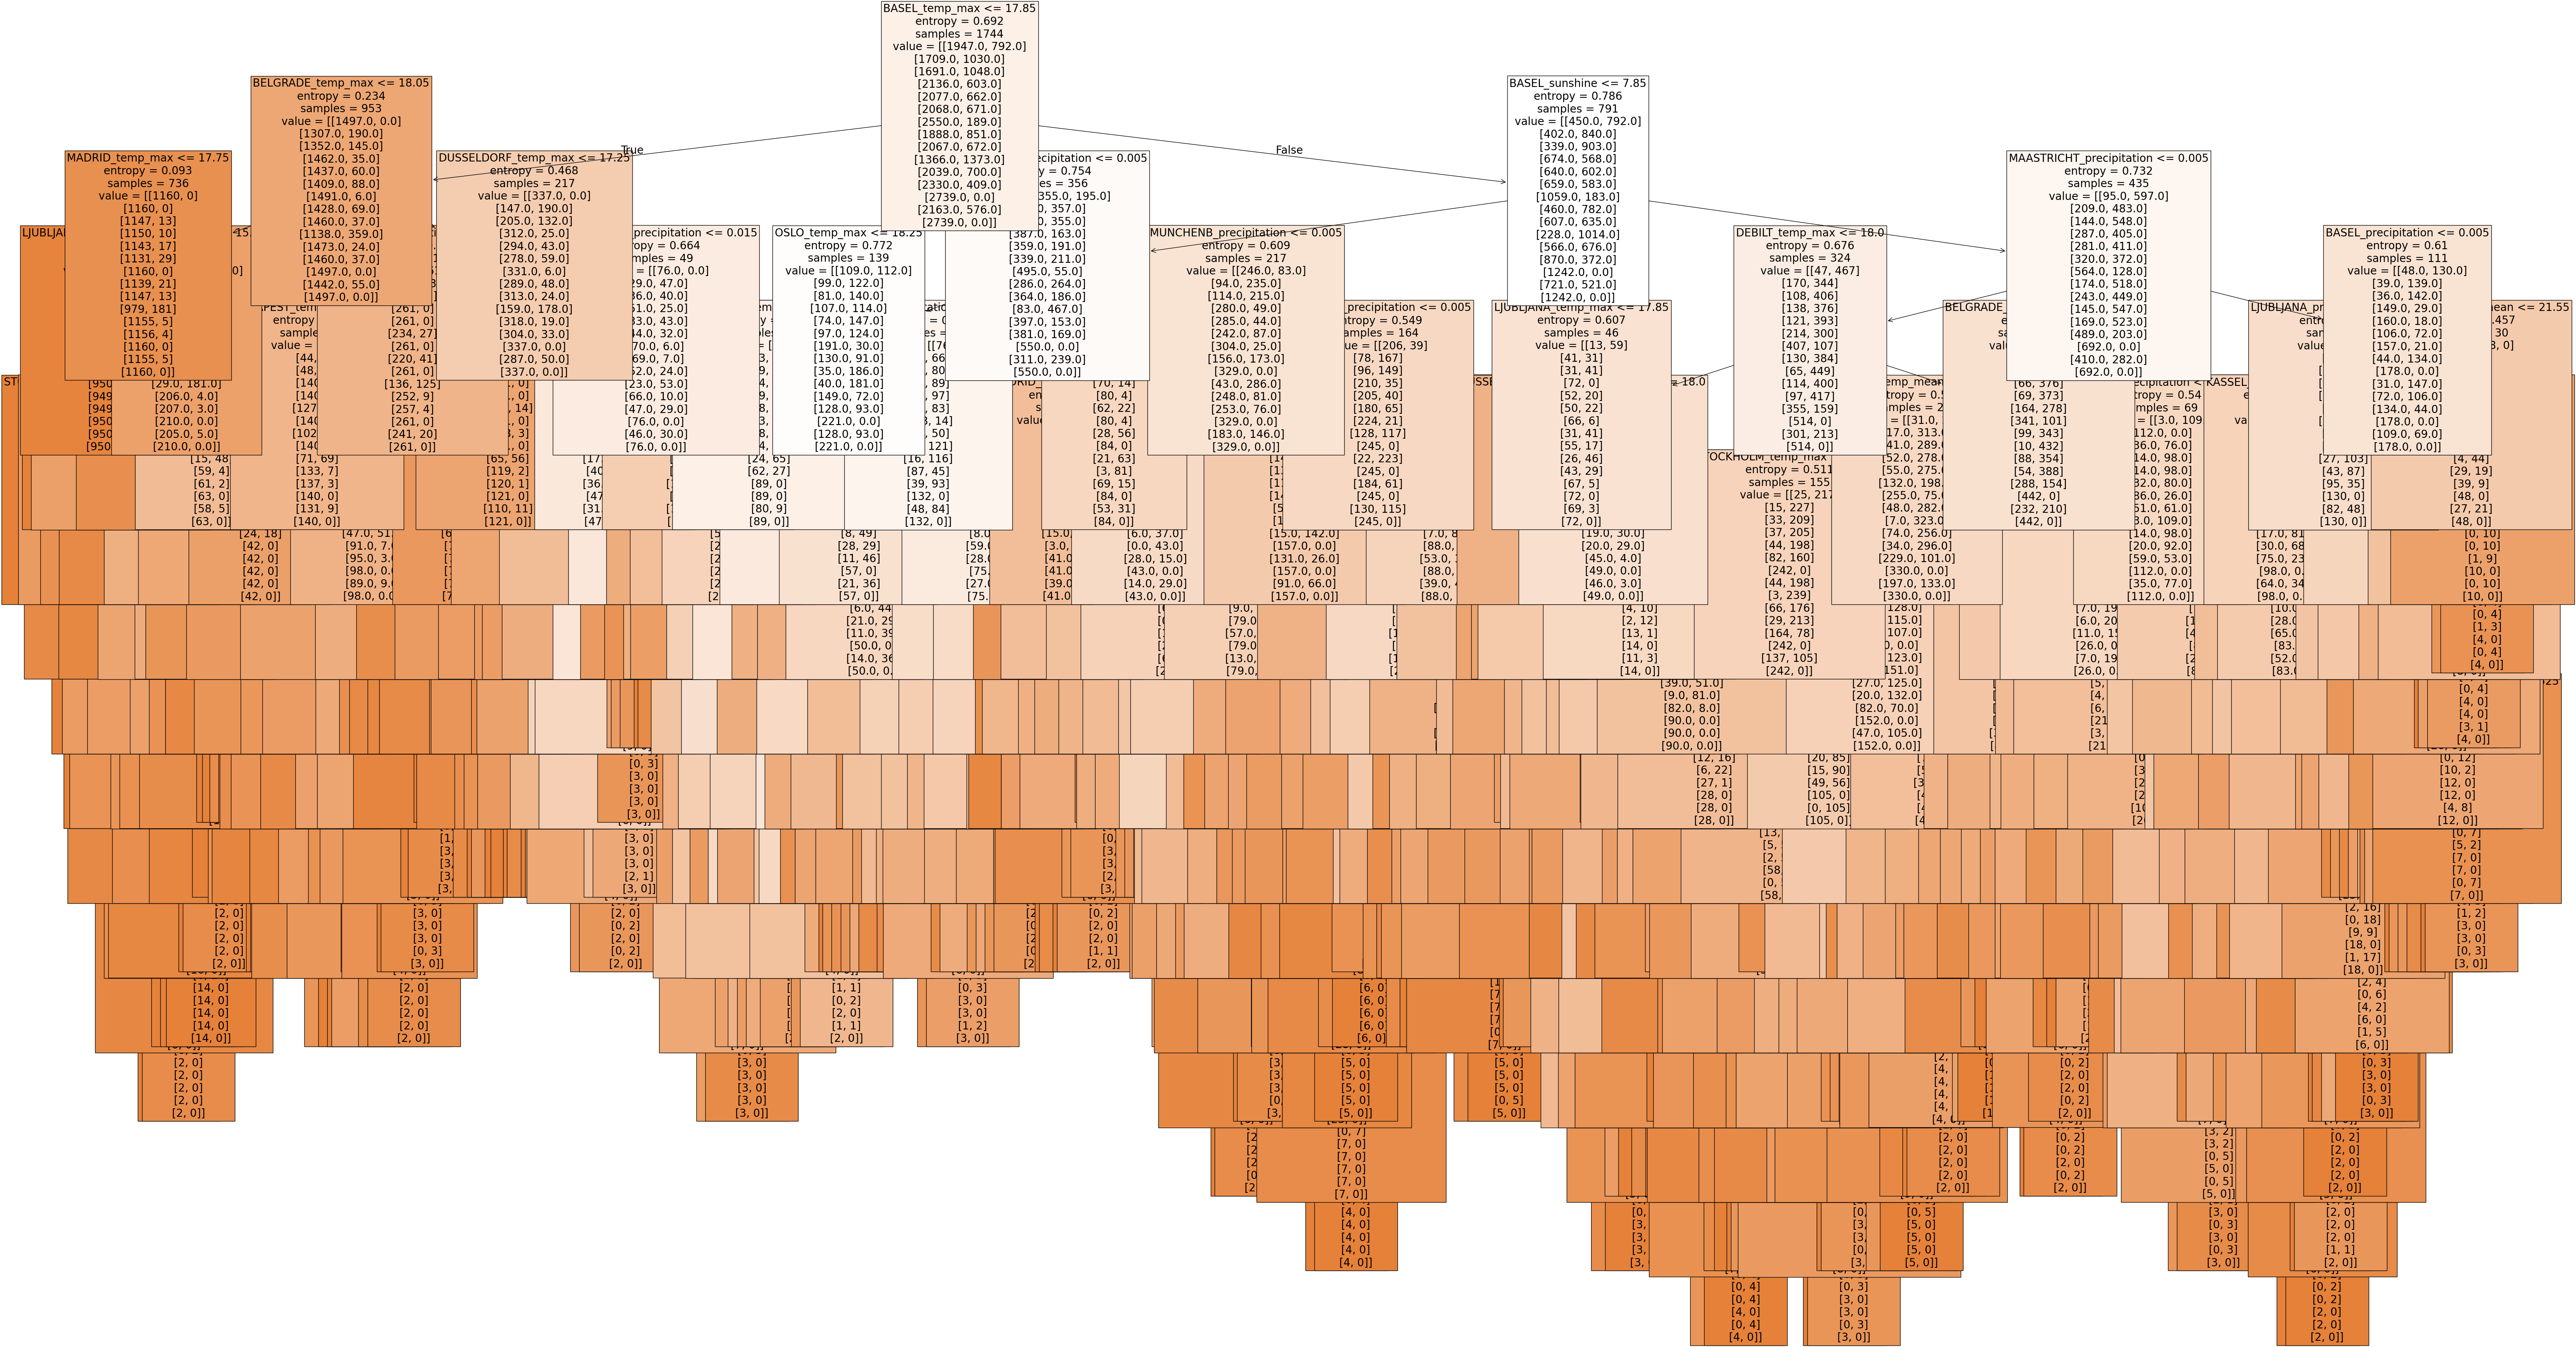

In [122]:
# Creating decision tree
fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[15], fontsize = 20, feature_names = climatedecade.columns, class_names=['unpleasant', 'pleasant'], filled=True);

In [124]:
# Saving the tree
fig.savefig(os.path.join(path, 'Achievement 2', 'random_forest_decade_optimized.png'), bbox_inches='tight')

#### 11. Feature importances

In [127]:
# Obtaining feature importances of the model
newarray = clf3.feature_importances_
#print(clf.feature_importances_.shape)
newarray

array([1.52563942e-03, 1.97765079e-03, 1.65979654e-03, 1.81939339e-03,
       3.05780727e-02, 3.99932462e-03, 1.14501864e-02, 1.34854552e-03,
       5.05320453e-02, 2.79845697e-03, 1.36778476e-03, 1.95299687e-03,
       1.32824088e-03, 3.12412766e-02, 1.98617750e-03, 4.16052510e-03,
       1.42404838e-03, 1.26581618e-02, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 2.59426605e-04, 2.38732881e-02, 3.22569168e-04,
       1.02485893e-02, 1.68634273e-03, 2.76195346e-02, 1.12181894e-03,
       1.52729994e-03, 1.79891029e-03, 1.98537788e-03, 1.72897160e-02,
       2.21491393e-03, 2.07914016e-03, 1.46383682e-03, 4.83165315e-02,
       9.61702439e-04, 1.27887962e-03, 1.67374462e-03, 2.15715546e-03,
       3.55771562e-02, 2.28282103e-03, 1.08042446e-02, 1.44118608e-03,
       1.21481018e-01, 1.62191452e-03, 2.58968898e-03, 2.16010539e-03,
       2.71333282e-03, 1.58862482e-02, 3.45507290e-03, 2.57074202e-03,
       1.54010945e-03, 9.38641839e-03, 7.50727931e-04, 1.08109469e-03,
      

In [129]:
# Checking the shape of newarray
newarray.shape

(135,)

In [131]:
# Reshaping newarray
newarray = newarray.reshape(-1,15,9)
print(newarray.shape)
newarray

(1, 15, 9)


array([[[1.52563942e-03, 1.97765079e-03, 1.65979654e-03, 1.81939339e-03,
         3.05780727e-02, 3.99932462e-03, 1.14501864e-02, 1.34854552e-03,
         5.05320453e-02],
        [2.79845697e-03, 1.36778476e-03, 1.95299687e-03, 1.32824088e-03,
         3.12412766e-02, 1.98617750e-03, 4.16052510e-03, 1.42404838e-03,
         1.26581618e-02],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.59426605e-04,
         2.38732881e-02, 3.22569168e-04, 1.02485893e-02, 1.68634273e-03,
         2.76195346e-02],
        [1.12181894e-03, 1.52729994e-03, 1.79891029e-03, 1.98537788e-03,
         1.72897160e-02, 2.21491393e-03, 2.07914016e-03, 1.46383682e-03,
         4.83165315e-02],
        [9.61702439e-04, 1.27887962e-03, 1.67374462e-03, 2.15715546e-03,
         3.55771562e-02, 2.28282103e-03, 1.08042446e-02, 1.44118608e-03,
         1.21481018e-01],
        [1.62191452e-03, 2.58968898e-03, 2.16010539e-03, 2.71333282e-03,
         1.58862482e-02, 3.45507290e-03, 2.57074202e-03, 1.54010945

In [133]:
# Collapsing the shape into one observation for each weather station
sumarray = np.sum(newarray[0], axis=1)
sumarray

array([0.10489065, 0.05891767, 0.06400975, 0.07779755, 0.17765791,
       0.04192363, 0.01750659, 0.09100349, 0.14276138, 0.07265003,
       0.05555623, 0.04192961, 0.01406066, 0.03758649, 0.00174837])

In [135]:
# Checking the shape of sumarray
sumarray.shape

(15,)

In [137]:
# Converting unique_stations to a list from a set
unique_stations = list(unique_stations)

In [139]:
# Obtaining the importances of each weather station
important = pd.Series(sumarray, index = unique_stations)
important

BUDAPEST      0.104891
MAASTRICHT    0.058918
KASSEL        0.064010
STOCKHOLM     0.077798
MUNCHENB      0.177658
VALENTIA      0.041924
DUSSELDORF    0.017507
DEBILT        0.091003
LJUBLJANA     0.142761
HEATHROW      0.072650
MADRID        0.055556
BASEL         0.041930
SONNBLICK     0.014061
OSLO          0.037586
BELGRADE      0.001748
dtype: float64

['BUDAPEST', 'MAASTRICHT', 'KASSEL', 'STOCKHOLM', 'MUNCHENB', 'VALENTIA', 'DUSSELDORF', 'DEBILT', 'LJUBLJANA', 'HEATHROW', 'MADRID', 'BASEL', 'SONNBLICK', 'OSLO', 'BELGRADE']


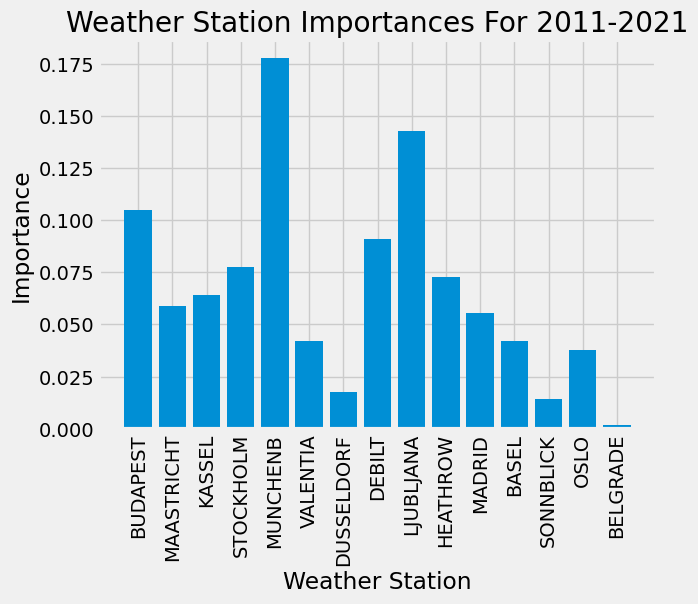

In [141]:
# Creating a bar chart of the importances of each weather station
%matplotlib inline

plt.style.use('fivethirtyeight')
x_values = list(range(len(important)))
print(unique_stations)

plt.bar(x_values, important, orientation = 'vertical')
plt.xticks(x_values, unique_stations, rotation='vertical')
plt.ylabel('Importance'); plt.xlabel('Weather Station'); plt.title('Weather Station Importances For 2011-2021');
plt.show()

In [245]:
# Saving the bar chart
plt.savefig(os.path.join(path, 'Achievement 2', 'weather_station_importances_optimized.png'), bbox_inches='tight')

#### 12. Subset and random forest for Munchenb

In [144]:
# Obtaining a list of columns in the climate dataset
list(climate)

['DATE',
 'MONTH',
 'BASEL_cloud_cover',
 'BASEL_wind_speed',
 'BASEL_humidity',
 'BASEL_pressure',
 'BASEL_global_radiation',
 'BASEL_precipitation',
 'BASEL_snow_depth',
 'BASEL_sunshine',
 'BASEL_temp_mean',
 'BASEL_temp_min',
 'BASEL_temp_max',
 'BELGRADE_cloud_cover',
 'BELGRADE_humidity',
 'BELGRADE_pressure',
 'BELGRADE_global_radiation',
 'BELGRADE_precipitation',
 'BELGRADE_sunshine',
 'BELGRADE_temp_mean',
 'BELGRADE_temp_min',
 'BELGRADE_temp_max',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_humidity',
 'BUDAPEST_pressure',
 'BUDAPEST_global_radiation',
 'BUDAPEST_precipitation',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'BUDAPEST_temp_max',
 'DEBILT_cloud_cover',
 'DEBILT_wind_speed',
 'DEBILT_humidity',
 'DEBILT_pressure',
 'DEBILT_global_radiation',
 'DEBILT_precipitation',
 'DEBILT_sunshine',
 'DEBILT_temp_mean',
 'DEBILT_temp_min',
 'DEBILT_temp_max',
 'DUSSELDORF_cloud_cover',
 'DUSSELDORF_wind_speed',
 'DUSSELDORF_humidity',
 'DUSSELDORF_pressure',
 

In [146]:
# Creating a subset with the columns for Munchenb
climate_munchenb = climate[['MUNCHENB_cloud_cover', 'MUNCHENB_humidity', 'MUNCHENB_global_radiation', 'MUNCHENB_precipitation', 'MUNCHENB_snow_depth',
 'MUNCHENB_sunshine', 'MUNCHENB_temp_mean', 'MUNCHENB_temp_min', 'MUNCHENB_temp_max']]

In [148]:
# Viewing the first five rows of climate_munchenb
climate_munchenb.head()

,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_snow_depth,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max
0,5,0.67,0.20,0.10,0,0.0,6.9,1.1,10.4
1,6,0.72,0.61,0.30,0,5.1,6.2,4.2,10.2
2,6,0.91,0.20,0.30,0,0.0,5.8,4.0,8.0
3,6,0.90,0.20,0.01,0,0.0,3.9,3.2,5.4
4,5,0.85,0.65,0.96,0,5.6,1.8,-3.0,6.0


In [150]:
# Checking the shape of climate_munchenb
climate_munchenb.shape

(22950, 9)

In [152]:
# Renaming climate_munchenb as X and creating y with the column for Munchenb from pleasantweather
X = climate_munchenb
y = pleasantweather['MUNCHENB_pleasant_weather']

In [154]:
# Converting X and Y into arrays
X = np.array(X)
y = np.array(y)

In [156]:
# Checking the shape of X
X.shape

(22950, 9)

In [158]:
# Checking the shape of y
y.shape

(22950,)

In [160]:
# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [162]:
# Printing the shapes of X_train, X_test, y_train, and y_test
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


#### 13. Grid Search for Munchenb

In [166]:
# Creating a RF classifier
clf = RandomForestClassifier()

In [168]:
# Grid search cv with a smaller number of iterations
grid_space={'max_depth':[3,10,None],
              'n_estimators':[10,100],
              'max_features':[15,50],
              'min_samples_leaf':[1,2],
              'min_samples_split':[2,3]
           }

In [170]:
start = time.time()
grid = GridSearchCV(clf,param_grid=grid_space,cv=3,scoring='accuracy', verbose=3, n_jobs=-1)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Search took 0.6150888005892435 minutes


In [172]:
# Printing grid search results
print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': 3, 'max_features': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Best GRID search score is: 1.0


#### 14. Random Search for Munchenb

In [175]:
# Random search cv
rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(15, 135),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1, 4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [177]:
# Creating a RF classifier
clf2= RandomForestClassifier()

In [179]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=10, scoring='accuracy', verbose=3, n_jobs=-1, cv=3) #500
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Search took 0.5426483511924743 minutes


In [181]:
# Printing random search results
print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': 40, 'max_features': 121, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 460}
Best RANDOM search score is: 1.0


In [183]:
# Printing grid search results vs.
print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))
# Printing random search results
print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best GRID search hyperparameters are: {'max_depth': 3, 'max_features': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}
Best GRID search score is: 1.0
Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': 40, 'max_features': 121, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 460}
Best RANDOM search score is: 1.0


The Grid Search and Random Search both have accuracy scores of 100%. The hyperparameters for either can be used for the random forest.

#### 15. Running random forest with optimized hyperparameters

In [223]:
# Creating a RF classifier with the best results from above
clf3 = RandomForestClassifier(n_estimators = 460, max_depth=40, max_features=121, min_samples_leaf=3, min_samples_split=6, criterion = 'entropy')  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=40, max_features=121,
                       min_samples_leaf=3, min_samples_split=6,
                       n_estimators=460)

In [224]:
# Performing predictions on the test dataset
y_pred = clf3.predict(X_test)
  
# Using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  1.0


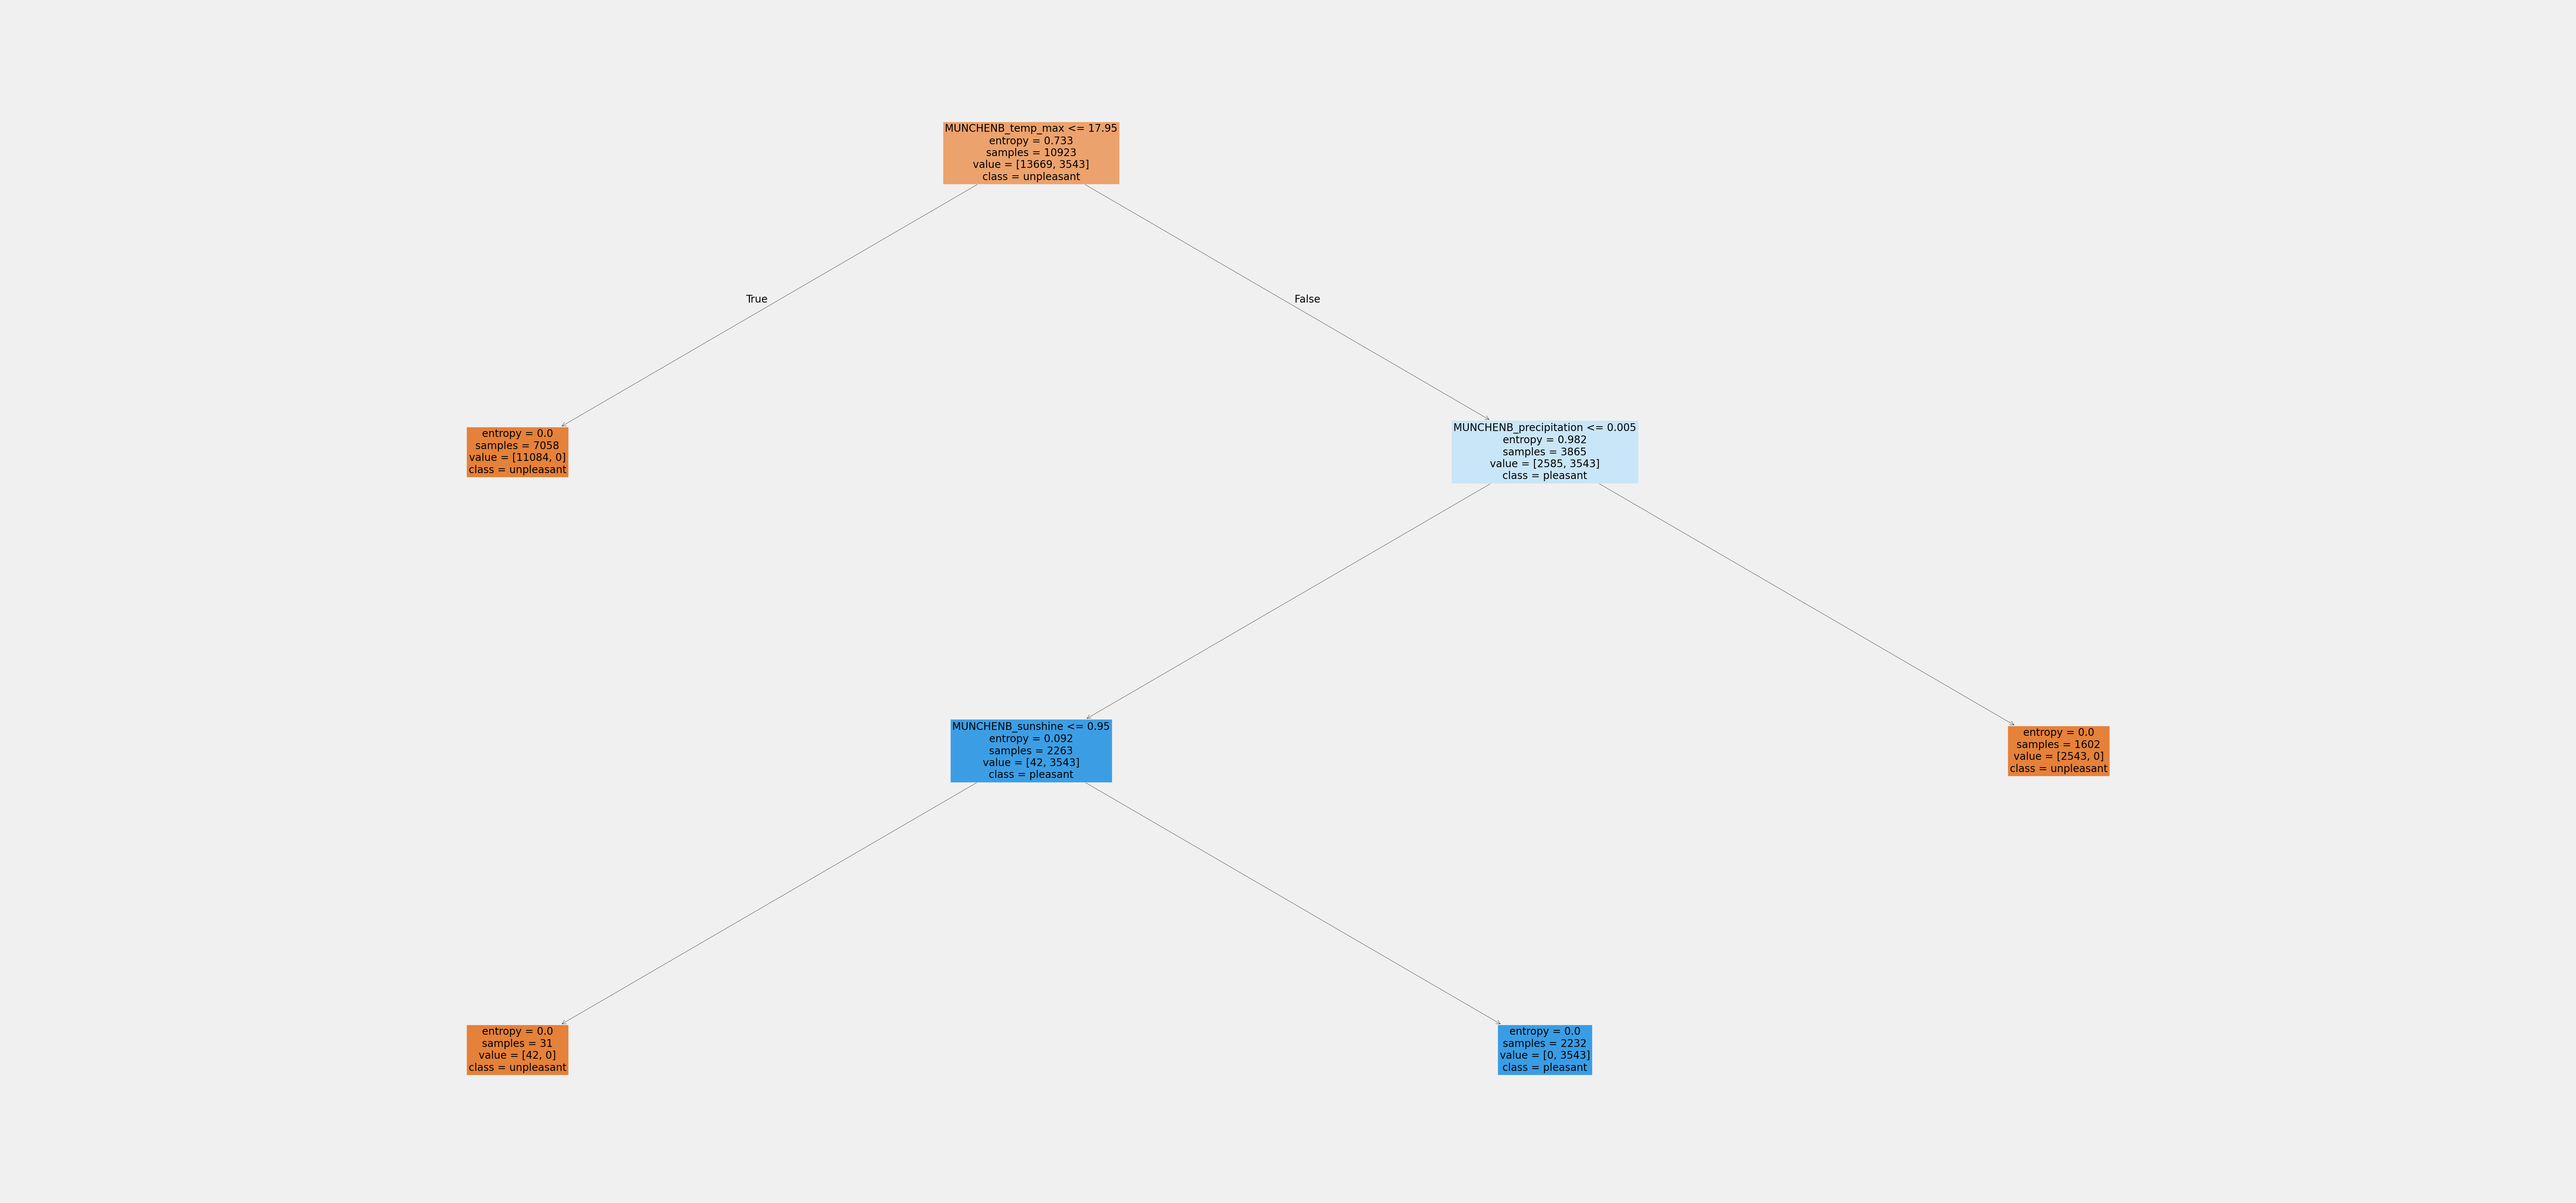

In [227]:
# Creating decision tree
fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[10], fontsize = 20, feature_names = climate_munchenb.columns, class_names=['unpleasant', 'pleasant'], filled=True);
plt.show()

In [229]:
# Saving the tree
fig.savefig(os.path.join(path, 'Achievement 2', 'decision_tree_munchenb_optimized.png'), bbox_inches='tight')

In [230]:
# Obtaining feature importances of the model
newarray = clf3.feature_importances_
#print(clf.feature_importances_.shape)
newarray

array([0.        , 0.        , 0.        , 0.44972251, 0.        ,
       0.02644173, 0.        , 0.        , 0.52383576])

In [233]:
# Checking the shape of newarray
newarray.shape

(9,)

In [235]:
# Creating a list of observations for Munchenb
munchenb_observations = ['cloud_cover', 'humidity', 'global_radiation', 'precipitation', 'snow_depth', 'sunshine', 'temp_mean', 'temp_min', 'temp_max']
munchenb_observations

['cloud_cover',
 'humidity',
 'global_radiation',
 'precipitation',
 'snow_depth',
 'sunshine',
 'temp_mean',
 'temp_min',
 'temp_max']

In [237]:
# Obtaining the importances of each observation for Munchenb
important = pd.Series(newarray, index = munchenb_observations)
important

cloud_cover         0.000000
humidity            0.000000
global_radiation    0.000000
precipitation       0.449723
snow_depth          0.000000
sunshine            0.026442
temp_mean           0.000000
temp_min            0.000000
temp_max            0.523836
dtype: float64

['cloud_cover', 'humidity', 'global_radiation', 'precipitation', 'snow_depth', 'sunshine', 'temp_mean', 'temp_min', 'temp_max']


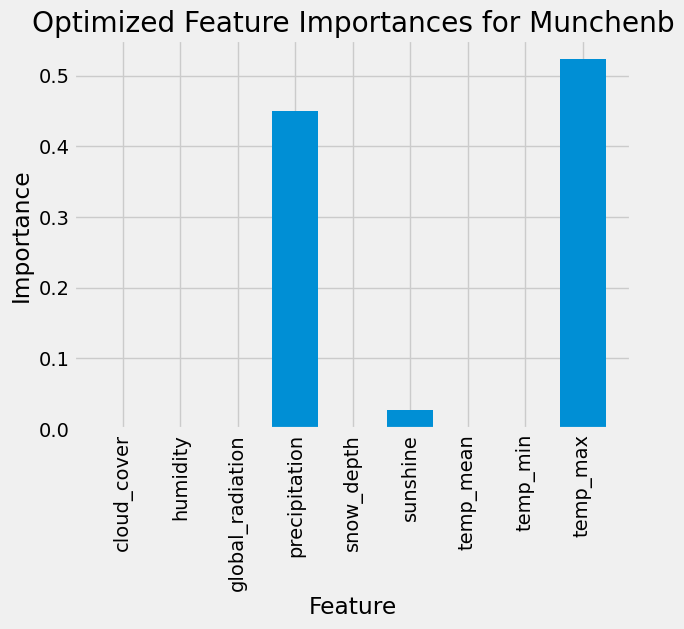

In [243]:
# Creating a bar chart of the importances of each observation for Kassel
%matplotlib inline

plt.style.use('fivethirtyeight')
x_values = list(range(len(important)))
print(munchenb_observations)

plt.bar(x_values, important, orientation = 'vertical')
plt.xticks(x_values, munchenb_observations, rotation='vertical')
plt.ylabel('Importance'); plt.xlabel('Feature'); plt.title('Optimized Feature Importances for Munchenb');
plt.show()

In [247]:
# Saving the bar chart
plt.savefig(os.path.join(path, 'Achievement 2', 'importances_Munchenb_optimized.png'), bbox_inches='tight')